In [15]:
import os
import gmsh
import numpy as np
import typing
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys 
sys.path.append("./")

class SensorArray:
    def __init__(self,filename: str) -> None:
        data = np.loadtxt(filename,delimiter=",",skiprows=1)
        self.NumberDatapoints = np.size(data,0)
        self.NodeCoordinates = data[:,1:4]
        self.RealValue = data[:,4:7]
        self.ElementCoordinates = data[:,7:10]
    
    def getNodeCoordinates(self,idx:  typing.Optional[np.ndarray] = None) -> np.ndarray:
        if idx == None:
            return self.NodeCoordinates[:,:]
        else:
            if not np.issubdtype(idx.dtype, np.integer):  
                raise ValueError("Index array must contain integers.")

            if np.any(idx < 0) or np.any(idx >= self.NumberDatapoints):  
                raise IndexError("Index out of range.")
            
            return self.NodeCoordinates[idx, :]
        
    def getElementCoordinates(self,idx:  typing.Optional[np.ndarray] = None) -> np.ndarray:
        if idx == None:
            return self.ElementCoordinates[:,:]
        else:
            if not np.issubdtype(idx.dtype, np.integer):  
                raise ValueError("Index array must contain integers.")

            if np.any(idx < 0) or np.any(idx >= self.NumberDatapoints):  
                raise IndexError("Index out of range.")
            
            return self.ElementCoordinates[idx, :]
        
def OperaTable(filename):
    with open(filename, "r") as file:
        lines = file.readlines()
    
    # Dewtermine number of datapoints
    first_line = lines[0].strip()
    counts = list(map(int, first_line.split()))
    num_data_points = counts[0] * counts[1] * counts[2] 
    
    # Extract Header
    column_names = []
    for line in lines[1:]:
        line = line.strip()
        if line == "0":  # Ende des Headers
            break
        column_name = re.sub(r"^\d+\s+|\[.*?\]", "", line).strip() 
        column_names.append(column_name)
    
    # Get Data
    data_start_index = lines.index(" 0\n") + 1  # First index after row with "0\n"
    data_lines = lines[data_start_index:data_start_index + num_data_points]
    
    # Convert Data
    data = [list(map(float, line.split())) for line in data_lines]
    df = pd.DataFrame(data, columns=column_names)
    
    return df

### Create the Mesh using Gmsh
For the Validation the following lines in the file "Coil3DVelocityAV.geo" need to be  
- Line 47: k = 12
- Line 49: q_h = 8

in order to have a better mesh which is similiar to the mesh of the reference solution in the comercial program opera. For the testcase the mesh is much coarser:
- Line 47: k = 2
- Line 49: q_h = 1

Additionaly the lines for the mesh-input, the surfRegionResults and the sensorArray need to be uncommented in the Coil3DVelocityAV.xml

In [16]:
%%capture output

gmsh.initialize()
gmsh.open(f"Coil3DVelocityAV_SUPG.geo")
gmsh.model.mesh.generate(3)
gmsh.write(f"Coil3DVelocityAV_SUPG.msh")
gmsh.finalize()

Info    : Reading 'Coil3DVelocityAV_SUPG.geo'...
Info    : Done reading 'Coil3DVelocityAV_SUPG.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (Line)
Info    : [ 10%] Meshing curve 10 (Line)
Info    : [ 10%] Meshing curve 11 (Line)
Info    : [ 10%] Meshing curve 12 (Line)
Info    : [ 10%] Meshing curve 13 (Line)
Info    : [ 10%] Meshing curve 14 (Line)
Info    : [ 10%] Meshing curve 15 (Line)
Info    : [ 10%] Meshing curve 16 (Line)
Info    : [ 10%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 18 (Line)
Info    : [ 10%] Meshing curve 19 (Line)
Info    : [ 10%] Meshing curve 20 (Line)
Info    : [ 10%] Meshing curve 21 (Line)
Info    : [ 10%] Meshing

### Load Results
For the validation the magnetic flux through the pole face and the electric current through the symmetrie plane in the region of the pole are compared. Additionally the fieldresults along a line in z-directions inside the moving conductor are compared.
#### openCFS

In [17]:
# Load magnetic Flux
with open("history/Coil3DVelocityAV_SUPG-magFlux-surfRegion-flux.csv", "r") as f:
    lines = f.readlines()
    
# Skip header
data = np.array([line.strip().split(",") for line in lines[1:]],dtype=float)
openCFS_Flux = np.abs(data[0,1])

# Load Current
with open("history/Coil3DVelocityAV_SUPG-magTotalCurrent-surfRegion-current.csv", "r") as f:
    lines = f.readlines()
    
# Skip header
data = np.array([line.strip().split(",") for line in lines[1:]],dtype=float)

openCFS_Current = np.abs(data[0,1])

# Read Sensor Array
openCFS_lineResult_Flux = SensorArray("sensorArray/flux_rail.csv-1")
openCFS_lineResult_Current = SensorArray("sensorArray/current_rail.csv-1")

#### Opera

In [18]:
# Global reference Solution 
opera = pd.read_csv("operaSolution_global.txt", delimiter=";", decimal=",", skipinitialspace=True)
opera_Flux = np.abs(float(opera.loc[0,"Flux"]))
opera_Current = np.abs(float(opera.loc[0,"Current"]))

# Read Line Results
opera_lineResults = OperaTable("operaSolution_lineResults.table")

### Comparison
#### Global Results

In [19]:
differenceFlux = openCFS_Flux - opera_Flux
differenceCurrent = openCFS_Current - opera_Current
relDifferenceFlux = differenceFlux/opera_Flux
relDifferenceCurrent = differenceCurrent/opera_Current
# Create a DataFrame with the results
data = {
    "openCFS": [openCFS_Flux, openCFS_Current],
    "Opera": [opera_Flux, opera_Current],
    "Difference": [differenceFlux, differenceCurrent],
    "relDifference in %": [relDifferenceFlux*100, relDifferenceCurrent*100]
}

# Define row labels
index_labels = ["Flux", "Current"]

# Create the DataFrame
df = pd.DataFrame(data, index=index_labels)

# Display the table
display(df)

,openCFS,Opera,Difference,relDifference in %
Flux,0.000006,0.000006,-2.446382e-07,-4.221014
Current,11.992470,7.730111,4.262359e+00,55.139688


#### Line Results

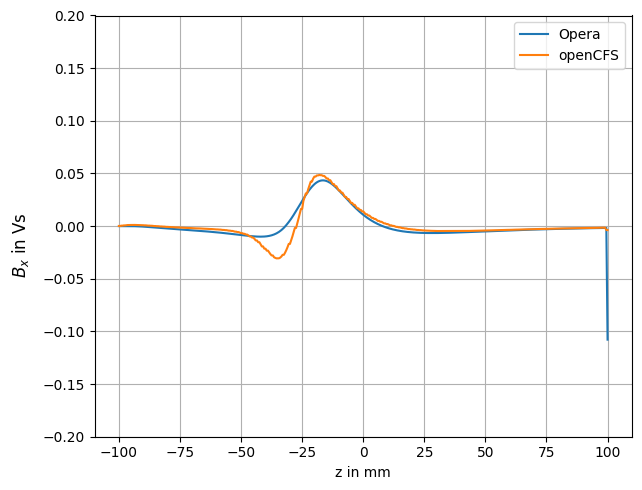

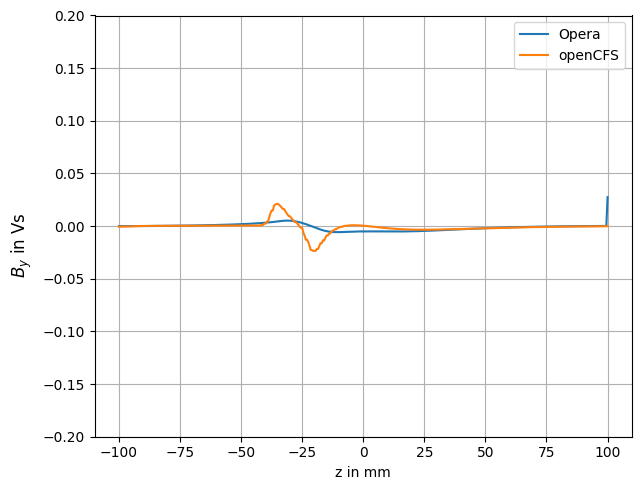

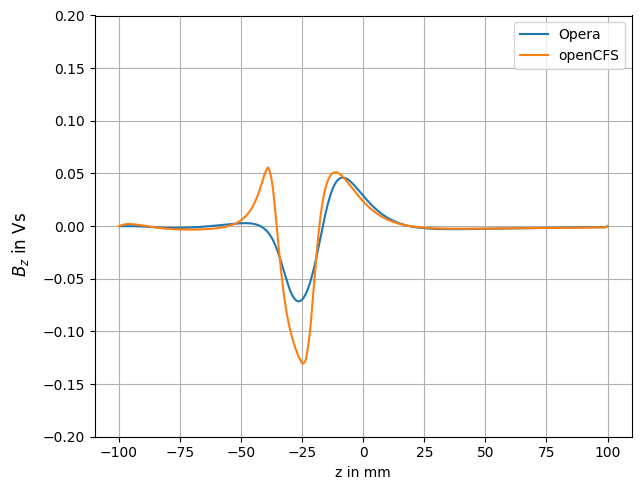

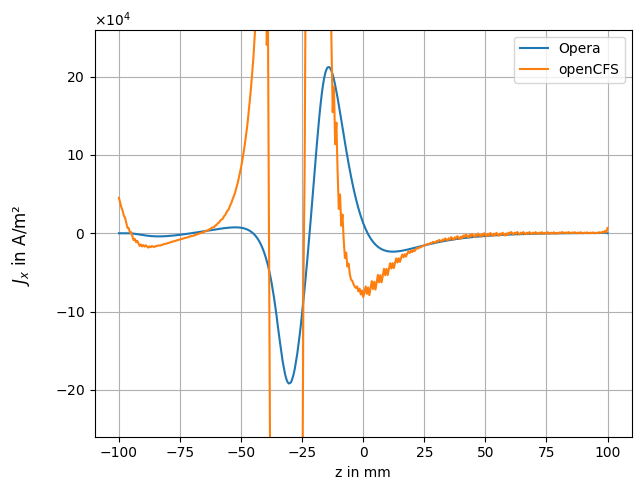

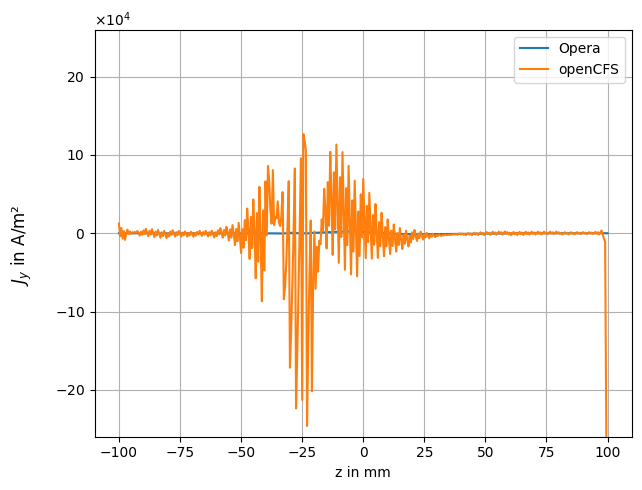

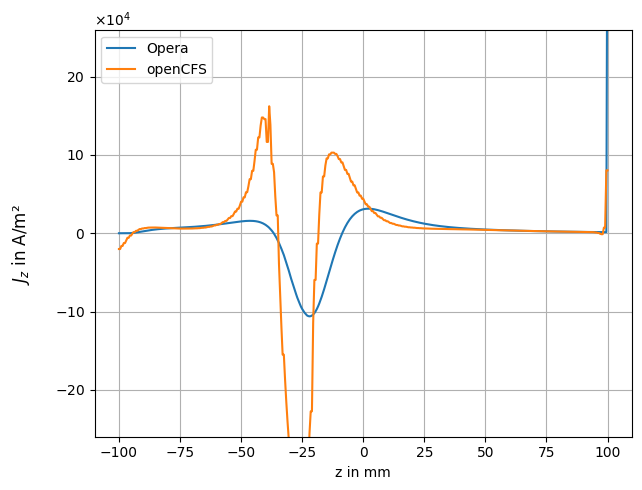

In [20]:
for j, component in enumerate(["B_x", "B_y", "B_z", "J_x", "J_y", "J_z"]):
    # Erstelle Subplots (eine Zeile mit N_velocities Spalten)
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
    ax.plot(1E3*opera_lineResults["Z"],opera_lineResults[component.replace("_", "")], linestyle='-',label=f"Opera")

    if j < 3: 
        cfsData = openCFS_lineResult_Flux
        unitStr = "Vs"
    elif j < 6: 
        cfsData = openCFS_lineResult_Current
        unitStr = "A/m²"
    cfsCoordinates = cfsData.getNodeCoordinates()
    ax.plot(1E3*cfsCoordinates[:,2],cfsData.RealValue[:,j%3], linestyle='-',label=f"openCFS")

    ax.set_xlabel("z in mm")
    ax.grid()
    if j < 3:
        ax.set_ylim(-0.2,0.2)
    elif j <6:
        ax.set_ylim(-26E4,26E4)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(4,4))  # Erzwingt 1e4-Format
    ax.legend()
    
    

    # Gemeinsame y-Achsen-Beschriftung für alle Subplots
    fig.supylabel(f"${component}$ in {unitStr}")

    # Layout anpassen und Plot anzeigen
    fig.tight_layout()
    fig.subplots_adjust(left=0.15)
    plt.show()